In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.spatial.distance import pdist, squareform

from sklearn.manifold import MDS

In [18]:
%run LittRuP__import_functions.ipynb

In [19]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [20]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [21]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [22]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [23]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Distance de Jaccard entre les thèmes**

In [24]:
# la distance de Jaccard est calculée entre toutes les paires de lignes :
# 65 thèmes => [65 x (65-1)]/2 paires (=2080)

MT = matrix_themes.T.to_numpy().astype(bool)

dist_jaccard_T = pdist(
    MT, 
    metric="jaccard"
)

**Recherche de n_init pour MDS**

In [25]:
import time

D = squareform(dist_jaccard_T)

resultats = []

for n in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    debut = time.perf_counter()

    mds = MDS(
        n_components=2,
        metric="precomputed",
        random_state=0,
        n_init=n,
        init="random",
        n_jobs=-1
    )

    coords = mds.fit_transform(D)

    fin = time.perf_counter()

    resultats.append({
        "n_init": n,
        "stress": mds.stress_,
        "temps_secondes": fin - debut
    })

df_stress = pd.DataFrame(resultats)
df_stress

,n_init,stress,temps_secondes
0,1,312.964152,2.010501
1,2,312.390768,1.619338
2,4,312.390768,1.951452
3,8,312.390768,1.577770
4,16,310.010906,0.173276
5,32,310.010906,0.289653
6,64,310.010906,0.561191
7,128,310.010906,1.191113
8,256,309.755347,2.418858
9,512,309.126230,4.723910


**Projection MDS en 2D**

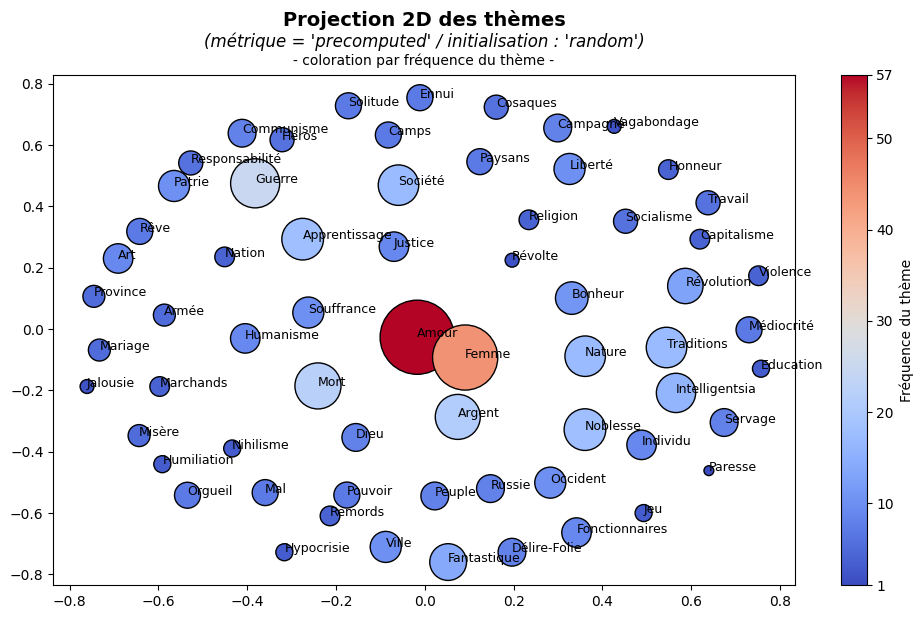

In [26]:

mds = MDS(
    n_components=2,
    metric="precomputed",
    random_state=0,
    n_init=16,
    init="random"
)

coords = mds.fit_transform(squareform(dist_jaccard_T))

theme_freq = matrix_themes.sum(axis=0)
vmin = theme_freq.min()
vmax = theme_freq.max()

fig, ax = plt.subplots(figsize=(10, 6))

# stocker l'objet scatter
sc = plt.scatter(
    coords[:,0],
    coords[:,1],
    c=theme_freq,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    s = theme_freq * 50,
    edgecolor="black"
)

for i, txt in enumerate(the_themes):
    plt.annotate(
        txt,
        (coords[i,0], coords[i,1]),
        fontsize=9,
        alpha=1.0
    )

# ajouter une barre de couleurs
cbar = plt.colorbar(sc)
cbar.set_label("Fréquence du thème")
ticks = [vmin,10,20,30,40,50,vmax]
cbar.set_ticks(ticks)

plt.tight_layout(rect=[0, 0, 1, 0.95])

titres(
    fig,
    ax,
    t1="Projection 2D des thèmes", y1=35,
    t2="(métrique = 'precomputed' / initialisation : 'random')", y2=20,
    t3="- coloration par fréquence du thème -", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_projection_2D_par_MDS.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()